--- Initializing MODIS QA for modis_extract.parquet ---

[1] Physical Range Check:
                lai  cloud_fraction  aerosol_fraction
count  1.710520e+07    1.949022e+07      1.949022e+07
mean   1.315355e+00    3.108866e+01      1.485187e+01
std    1.499280e+00    3.086987e+01      1.809486e+01
min    0.000000e+00    0.000000e+00      0.000000e+00
25%    2.160150e-01    3.500000e+00      0.000000e+00
50%    6.666667e-01    1.875000e+01      7.500000e+00
75%    1.880335e+00    5.500000e+01      2.250000e+01
max    7.000000e+00    1.000000e+02      1.000000e+02
Records with LAI > 10.0: 0 (0.0000%)

[2] Spatial Consistency Check:


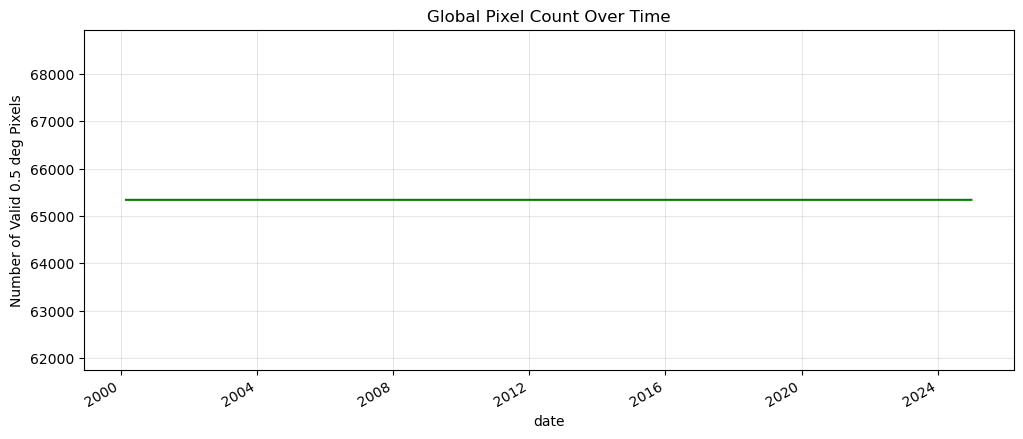

Mean pixels per timestamp: 65341.0
Coefficient of Variation in coverage: 0.0000

[3] Temporal Snapping Check:
Success: All dates strictly follow the 8-day snapping (1, 9, 17...).

[4] Quality Flag Analysis:
Average LAI by Quality Bin (Higher bin = potentially lower quality):
quality_flag
(0, 1]       0.234619
(1, 2]       0.246214
(2, 5]       0.252860
(5, 10]      0.245150
(10, 100]    1.124505
Name: lai, dtype: float32


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pq

class ModisQA:
    def __init__(self, file_path):
        self.file_path = Path(file_path)
        print(f"--- Initializing MODIS QA for {self.file_path.name} ---")
        # Reading a sample or full file depending on size
        self.df = pd.read_parquet(self.file_path)
        self.df['date'] = pd.to_datetime(self.df['date'])

    def check_physical_ranges(self):
        """Validates if LAI and Fraction values are within physical bounds."""
        print("\n[1] Physical Range Check:")
        # LAI typically ranges from 0 to 7-10 m2/m2. 
        # MODIS LAI fill values are usually > 250 in raw, should be NaN/small in processed.
        stats = self.df[['lai', 'cloud_fraction', 'aerosol_fraction']].describe()
        print(stats)
        
        # Flagging extreme LAI
        extreme_lai = (self.df['lai'] > 10.0).sum()
        print(f"Records with LAI > 10.0: {extreme_lai} ({extreme_lai/len(self.df)*100:.4f}%)")

    def check_spatial_consistency(self):
        """Analyzes spatial coverage and grid integrity."""
        print("\n[2] Spatial Consistency Check:")
        
        # Count unique pixels per date
        coverage_over_time = self.df.groupby('date').size()
        
        plt.figure(figsize=(12, 5))
        coverage_over_time.plot(title="Global Pixel Count Over Time", color='green')
        plt.ylabel("Number of Valid 0.5 deg Pixels")
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"Mean pixels per timestamp: {coverage_over_time.mean():.1f}")
        print(f"Coefficient of Variation in coverage: {coverage_over_time.std()/coverage_over_time.mean():.4f}")

    def check_temporal_snapping(self):
        """Validates if dates strictly follow the 8-day MODIS schedule."""
        print("\n[3] Temporal Snapping Check:")
        days_of_year = self.df['date'].dt.dayofyear.unique()
        # Standard MODIS 8-day intervals: 1, 9, 17, 25...
        expected_doys = set(range(1, 362, 8))
        
        unexpected = [d for d in days_of_year if d not in expected_doys]
        if not unexpected:
            print("Success: All dates strictly follow the 8-day snapping (1, 9, 17...).")
        else:
            print(f"Warning: Found {len(unexpected)} non-standard DOYs: {unexpected[:5]}...")

    def check_quality_impact(self):
        """Correlates Quality Flags with LAI values."""
        print("\n[4] Quality Flag Analysis:")
        # Grouping by quality_flag to see LAI distribution
        # Note: In your ETL, quality_flag is a mean of native pixels
        quality_bins = pd.cut(self.df['quality_flag'], bins=[0, 1, 2, 5, 10, 100])
        q_analysis = self.df.groupby(quality_bins, observed=True)['lai'].mean()
        print("Average LAI by Quality Bin (Higher bin = potentially lower quality):")
        print(q_analysis)

    def run_all(self):
        self.check_physical_ranges()
        self.check_spatial_consistency()
        self.check_temporal_snapping()
        self.check_quality_impact()

# Path to your interim MODIS file
modis_path = Path("../data/interim/modis_extract.parquet")
if modis_path.exists():
    qa = ModisQA(modis_path)
    qa.run_all()
else:
    print(f"File not found: {modis_path}")

--- Generating Geographical Map for modis_extract.parquet ---


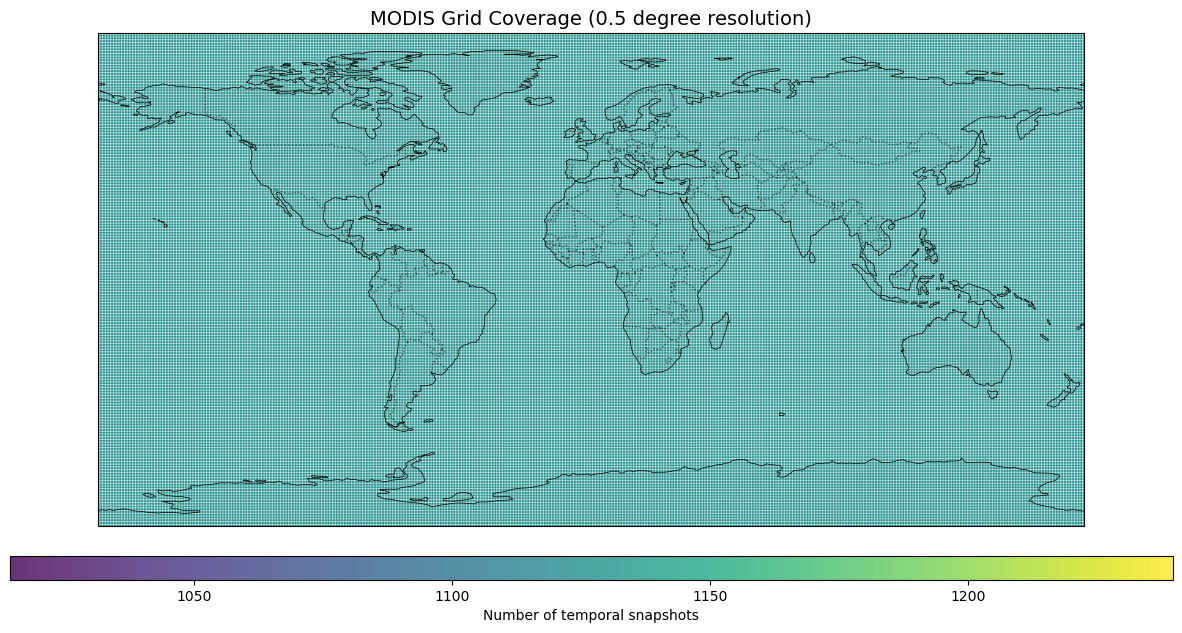

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

def plot_modis_geography(file_path):
    print(f"--- Generating Geographical Map for {file_path.name} ---")
    
    # Load data
    df = pd.read_parquet(file_path, columns=['latitude', 'longitude', 'lai'])
    
    # Since we have millions of rows (multiple dates), 
    # we'll aggregate by coordinate to see the unique "station" locations
    unique_grid = df.groupby(['latitude', 'longitude']).size().reset_index(name='observation_count')

    plt.figure(figsize=(15, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features for context
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)

    # Plot the grid points
    # Color represents how many 8-day snapshots we have for each pixel
    sc = plt.scatter(unique_grid['longitude'], unique_grid['latitude'], 
                     c=unique_grid['observation_count'], 
                     cmap='viridis', s=1, alpha=0.8, transform=ccrs.PlateCarree())

    plt.colorbar(sc, label='Number of temporal snapshots', orientation='horizontal', pad=0.05, aspect=50)
    plt.title("MODIS Grid Coverage (0.5 degree resolution)", fontsize=14)
    
    plt.show()

# Run visualization
modis_path = Path("../data/interim/modis_extract.parquet")
if modis_path.exists():
    plot_modis_geography(modis_path)